-----

In [41]:
# def min_max_normalization(x):
#     return (x - x.min()) / (x.max() - x.min())

# def denormalize(df_norm, orig_min, orig_max):
#     return df_norm * (orig_max - orig_min) + orig_min

# numeric_cols = sampled_data.select_dtypes(include=[np.number])

# orig_min = numeric_cols.min()
# orig_max = numeric_cols.max()

# min_max_data = numeric_cols.apply(min_max_normalization)

# min_max_data  = min_max_data.drop(['int.rate', 'installment', 'log.annual.inc'], axis=1)

# categorical_cols = sampled_data.select_dtypes(exclude=[np.number])
# full_min_max_data = pd.concat([min_max_data, categorical_cols], axis=1)

# min_max_data.head()

In [42]:
# debt_data = full_min_max_data[full_min_max_data['purpose'] == 'debt_consolidation']
# credit_data = full_min_max_data[full_min_max_data['purpose'] == 'credit_card']

In [43]:
# X_train_debt, X_test_debt, y_train_debt, y_test_debt = train_test_split(debt_data.iloc[:, :-3], debt_data['credit.policy'], test_size=0.2, random_state=123)

# X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(credit_data.iloc[:, :-3], credit_data['credit.policy'], test_size=0.2, random_state=123)

In [44]:
# X_debt, y_debt = debt_data.iloc[:, :-3], debt_data['credit.policy']

# X_credit, y_credit = credit_data.iloc[:, :-3], credit_data['credit.policy']

-----

# Bibliotekos

In [45]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn import svm
from sklearn.ensemble import AdaBoostClassifier as AdaBoost
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import SGDClassifier

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.manifold import TSNE
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import make_scorer, recall_score

# Duomenys

In [46]:
file_path = os.path.join("..", "1_laboratorinis", "loan_data.csv")
data = pd.read_csv(file_path)

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    data[col] = data[col].astype('category')

data['annual.inc'] = np.exp(data['log.annual.inc'])

print(f"Eilučių skaičius: {len(data)}")
print(f"Stulpelių skaičius: {len(data.columns)}")

Eilučių skaičius: 9578
Stulpelių skaičius: 15


In [77]:
sampled_data = data.groupby(['purpose', 'credit.policy'], observed=False).sample(
    frac=0.6, 
    random_state=6202
).reset_index(drop=True)

print(f"\nAtrinktų duomenų dydis: {len(sampled_data)}")


Atrinktų duomenų dydis: 5746


In [48]:
debt_data = sampled_data[sampled_data['purpose'] == 'debt_consolidation']
debt_data = debt_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc'])
debt_data.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
2156,0,26.40,697,3840.000000,5132,41.4,2,0,0,0,45000.000056
2157,0,13.02,687,2130.000000,9451,33.3,4,0,0,1,37499.999927
2158,0,19.52,672,4529.958333,8443,33.2,4,1,0,0,38000.000049
2159,0,16.19,672,6360.000000,5494,83.2,4,0,0,0,60999.999808
2160,0,26.52,667,2672.958333,21300,65.5,4,0,0,0,55199.999875


In [49]:
print(debt_data['credit.policy'].value_counts())
print(debt_data['credit.policy'].value_counts(normalize=True))

credit.policy
1    1934
0     440
Name: count, dtype: int64
credit.policy
1    0.814659
0    0.185341
Name: proportion, dtype: float64


In [50]:
credit_data = sampled_data[sampled_data['purpose'] == 'credit_card']
credit_data = credit_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc'])
credit_data.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
1399,0,16.87,677,3779.958333,2488,62.2,5,0,0,0,34999.999983
1400,0,15.14,647,3299.000000,36662,82.9,0,0,0,0,49999.999779
1401,0,4.51,727,600.000000,669,7.0,0,0,0,0,49999.999779
1402,0,6.24,657,2490.000000,8558,80.7,3,0,0,0,71000.000282
1403,0,12.26,702,6960.000000,56200,57.4,4,0,0,0,159999.999325


In [51]:
print(credit_data['credit.policy'].value_counts())
print(credit_data['credit.policy'].value_counts(normalize=True))

credit.policy
1    612
0    145
Name: count, dtype: int64
credit.policy
1    0.808454
0    0.191546
Name: proportion, dtype: float64


In [52]:
X_debt = debt_data.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_debt = debt_data['credit.policy']

X_credit = credit_data.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_credit = credit_data['credit.policy']

In [53]:
X_debt.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
2156,26.40,697,3840.000000,5132,41.4,2,0,0,45000.000056
2157,13.02,687,2130.000000,9451,33.3,4,0,0,37499.999927
2158,19.52,672,4529.958333,8443,33.2,4,1,0,38000.000049
2159,16.19,672,6360.000000,5494,83.2,4,0,0,60999.999808
2160,26.52,667,2672.958333,21300,65.5,4,0,0,55199.999875


In [54]:
debt_data.corr()['credit.policy']

credit.policy        1.000000
dti                 -0.121231
fico                 0.343442
days.with.cr.line    0.080150
revol.bal           -0.180822
revol.util          -0.113900
inq.last.6mths      -0.577683
delinq.2yrs         -0.075885
pub.rec             -0.060436
not.fully.paid      -0.117295
annual.inc           0.006409
Name: credit.policy, dtype: float64

# Algoritmai su numatytais parametrais

## Kredito politika, visi požymiai, specifiškumas
## Kryžminė validacija

In [55]:
cv_strategy = StratifiedKFold(n_splits=20, shuffle=True, random_state=123)
specificity_scorer = make_scorer(recall_score, pos_label=0)

### SVC

In [56]:
svc_pipeline = make_pipeline(MinMaxScaler(), svm.SVC())

# scores_svc_debt = cross_val_score(svc_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_svc_debt.mean()}")

# scores_svc_credit = cross_val_score(svc_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_svc_credit.mean()}")


scores_svc_debt = cross_val_score(svc_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_svc_debt.mean():.4f}")

scores_svc_credit = cross_val_score(svc_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_svc_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.6705
Kredito kortelės (Specifiškumas): 0.4482


### AdaBoost

In [57]:
AdaBoost_pipeline = make_pipeline(MinMaxScaler(), AdaBoost())

# scores_AdaBoost_debt = cross_val_score(svc_AdaBoost_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_AdaBoost_debt.mean()}")

# scores_AdaBoost_credit = cross_val_score(svc_AdaBoost_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_AdaBoost_credit.mean()}")

scores_AdaBoost_debt = cross_val_score(AdaBoost_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_AdaBoost_debt.mean():.4f}")

scores_AdaBoost_credit = cross_val_score(AdaBoost_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_AdaBoost_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.8705
Kredito kortelės (Specifiškumas): 0.7366


### Bernoulli naive bayes

In [58]:
BernoulliNB_pipeline = make_pipeline(MinMaxScaler(), BernoulliNB())

# scores_BernoulliNB_debt = cross_val_score(svc_BernoulliNB_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_BernoulliNB_debt.mean()}")

# scores_BernoulliNB_credit = cross_val_score(svc_BernoulliNB_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_BernoulliNB_credit.mean()}")

scores_BernoulliNB_debt = cross_val_score(BernoulliNB_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_BernoulliNB_debt.mean():.4f}")

scores_BernoulliNB_credit = cross_val_score(BernoulliNB_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_BernoulliNB_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.0045
Kredito kortelės (Specifiškumas): 0.0286


### Logistic Regression

In [59]:
lr_pipeline = make_pipeline(MinMaxScaler(), LogisticRegression())

# scores_lr_debt = cross_val_score(svc_lr_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_lr_debt.mean()}")

# scores_lr_credit = cross_val_score(svc_lr_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_lr_credit.mean()}")

scores_lr_debt = cross_val_score(lr_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_lr_debt.mean():.4f}")

scores_lr_credit = cross_val_score(lr_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_lr_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.5386
Kredito kortelės (Specifiškumas): 0.2473


### Gradient Boosting

In [60]:
gb_pipeline = make_pipeline(MinMaxScaler(), GradientBoostingClassifier())

# scores_gb_debt = cross_val_score(gb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_gb_debt.mean()}")

# scores_gb_credit = cross_val_score(gb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_gb_credit.mean()}")

scores_gb_debt = cross_val_score(gb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gb_debt.mean():.4f}")

scores_gb_credit = cross_val_score(gb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gb_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.9682
Kredito kortelės (Specifiškumas): 0.8893


### Gaussian Naive Bayes

In [61]:
gnb_pipeline = make_pipeline(MinMaxScaler(), GaussianNB())

# scores_gnb_debt = cross_val_score(gnb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_gnb_debt.mean()}")

# scores_gnb_credit = cross_val_score(gnb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_gnb_credit.mean()}")

scores_gnb_debt = cross_val_score(gnb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gnb_debt.mean():.4f}")

scores_gnb_credit = cross_val_score(gnb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gnb_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.6455
Kredito kortelės (Specifiškumas): 0.4884


### Random Forest

In [62]:
rf_pipeline = make_pipeline(MinMaxScaler(), RandomForestClassifier())

# scores_rf_debt = cross_val_score(rf_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_rf_debt.mean()}")

# scores_rf_credit = cross_val_score(rf_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_rf_credit.mean()}")

scores_rf_debt = cross_val_score(rf_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_rf_debt.mean():.4f}")

scores_rf_credit = cross_val_score(rf_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_rf_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.9636
Kredito kortelės (Specifiškumas): 0.8821


### K-Nearest Neighbors

In [63]:
knn_pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier())

# scores_knn_debt = cross_val_score(knn_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_knn_debt.mean()}")

# scores_knn_credit = cross_val_score(knn_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_knn_credit.mean()}")

scores_knn_debt = cross_val_score(knn_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_knn_debt.mean():.4f}")

scores_knn_credit = cross_val_score(knn_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_knn_credit.mean():.4f}")

Konsolidavimo (Specifiškumas): 0.5364
Kredito kortelės (Specifiškumas): 0.3107


### Passive Aggressive

In [64]:
pa_pipeline = make_pipeline(MinMaxScaler(), PassiveAggressiveClassifier())

# scores_pa_debt = cross_val_score(pa_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
# print(f"Konsolidavimo: {scores_pa_debt.mean()}")

# scores_pa_credit = cross_val_score(pa_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
# print(f"Kredito kortelės: {scores_pa_credit.mean()}")

scores_pa_debt = cross_val_score(pa_pipeline, X_debt, y_debt, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_pa_debt.mean():.4f}")

scores_pa_credit = cross_val_score(pa_pipeline, X_credit, y_credit, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_pa_credit.mean():.4f}")

c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', pe

Konsolidavimo (Specifiškumas): 0.6455
Kredito kortelės (Specifiškumas): 0.6509


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', pe

-----

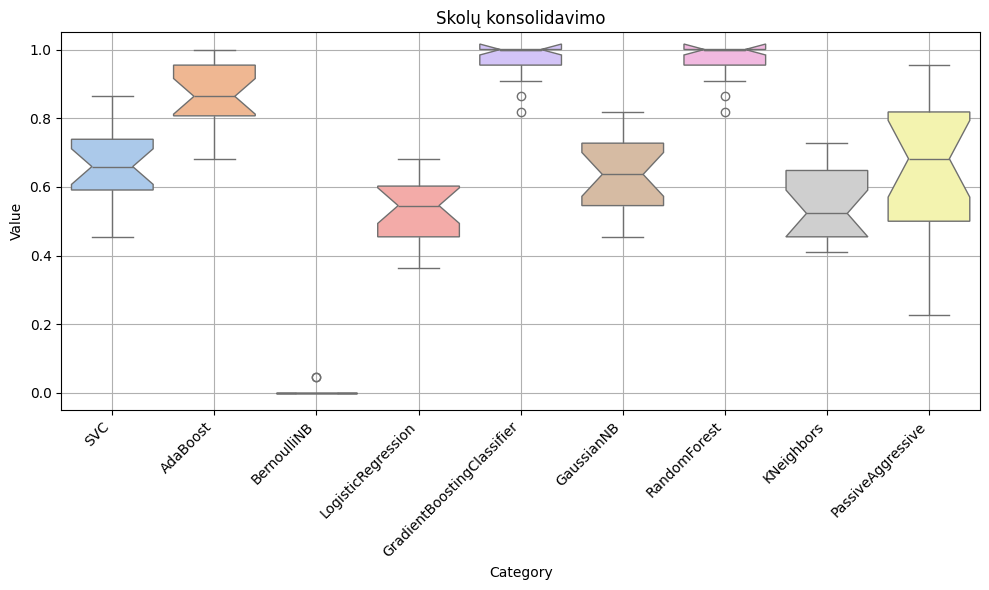

In [65]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20 + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_debt, scores_AdaBoost_debt, scores_BernoulliNB_debt, scores_lr_debt, scores_gb_debt, scores_gnb_debt, scores_rf_debt, scores_knn_debt, scores_pa_debt])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Skolų konsolidavimo")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

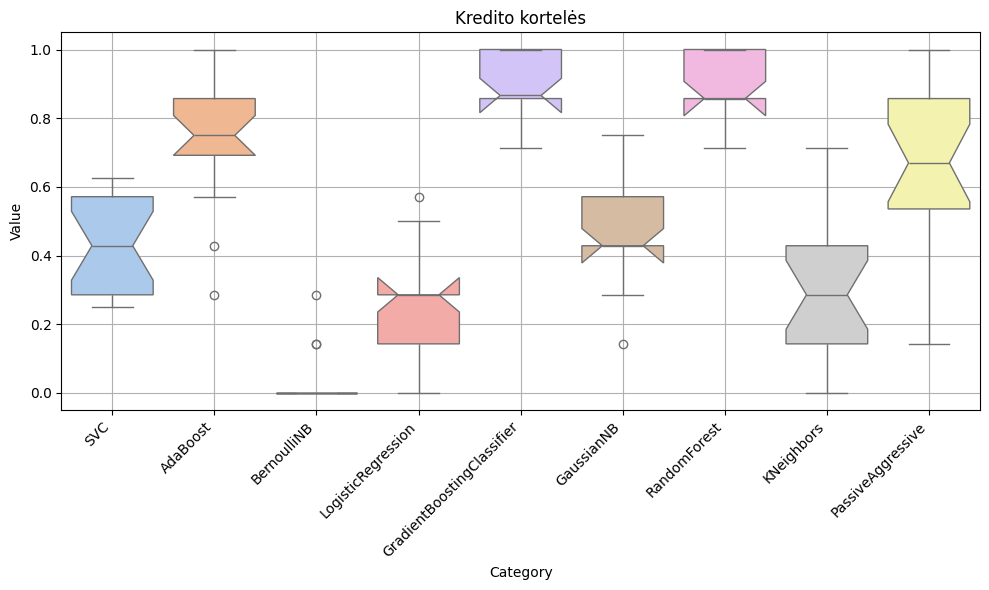

In [66]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20  + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_credit, scores_AdaBoost_credit, scores_BernoulliNB_credit, scores_lr_credit, scores_gb_credit, scores_gnb_credit, scores_rf_credit, scores_knn_credit, scores_pa_credit])
})


plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Kredito kortelės")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

## Kredito politika, atrinkti požymiai, specifiškumas

In [76]:
sampled_data_for_cor = sampled_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc'])
sampled_data_for_cor.corr()['credit.policy']

credit.policy        1.000000
dti                 -0.088296
fico                 0.350932
days.with.cr.line    0.101034
revol.bal           -0.166751
revol.util          -0.099667
inq.last.6mths      -0.537416
delinq.2yrs         -0.084831
pub.rec             -0.053964
not.fully.paid      -0.140666
annual.inc           0.000052
Name: credit.policy, dtype: float64

In [78]:
debt_data_subset = sampled_data[sampled_data['purpose'] == 'debt_consolidation']
debt_data_subset = debt_data_subset.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'inq.last.6mths', 'fico'])
debt_data_subset.head()

,credit.policy,dti,days.with.cr.line,revol.bal,revol.util,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
2156,0,26.40,3840.000000,5132,41.4,0,0,0,45000.000056
2157,0,13.02,2130.000000,9451,33.3,0,0,1,37499.999927
2158,0,19.52,4529.958333,8443,33.2,1,0,0,38000.000049
2159,0,16.19,6360.000000,5494,83.2,0,0,0,60999.999808
2160,0,26.52,2672.958333,21300,65.5,0,0,0,55199.999875


In [79]:
credit_data_subset = sampled_data[sampled_data['purpose'] == 'credit_card']
credit_data_subset = credit_data_subset.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'inq.last.6mths', 'fico'])
credit_data_subset.head()

,credit.policy,dti,days.with.cr.line,revol.bal,revol.util,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
1399,0,16.87,3779.958333,2488,62.2,0,0,0,34999.999983
1400,0,15.14,3299.000000,36662,82.9,0,0,0,49999.999779
1401,0,4.51,600.000000,669,7.0,0,0,0,49999.999779
1402,0,6.24,2490.000000,8558,80.7,0,0,0,71000.000282
1403,0,12.26,6960.000000,56200,57.4,0,0,0,159999.999325


In [80]:
X_debt_subset = debt_data_subset.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_debt_subset = debt_data_subset['credit.policy']

X_credit_subset = credit_data_subset.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_credit_subset = credit_data_subset['credit.policy']

Konsolidavimo (Specifiškumas): 0.0545
Kredito kortelės (Specifiškumas): 0.0339
Konsolidavimo (Specifiškumas): 0.2614
Kredito kortelės (Specifiškumas): 0.1804
Konsolidavimo (Specifiškumas): 0.0045
Kredito kortelės (Specifiškumas): 0.0357
Konsolidavimo (Specifiškumas): 0.0432
Kredito kortelės (Specifiškumas): 0.0196
Konsolidavimo (Specifiškumas): 0.3000
Kredito kortelės (Specifiškumas): 0.3679
Konsolidavimo (Specifiškumas): 0.2295
Kredito kortelės (Specifiškumas): 0.2437
Konsolidavimo (Specifiškumas): 0.3000
Kredito kortelės (Specifiškumas): 0.3464
Konsolidavimo (Specifiškumas): 0.1568
Kredito kortelės (Specifiškumas): 0.1437


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', pe

Konsolidavimo (Specifiškumas): 0.1000


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', pe

Kredito kortelės (Specifiškumas): 0.1411


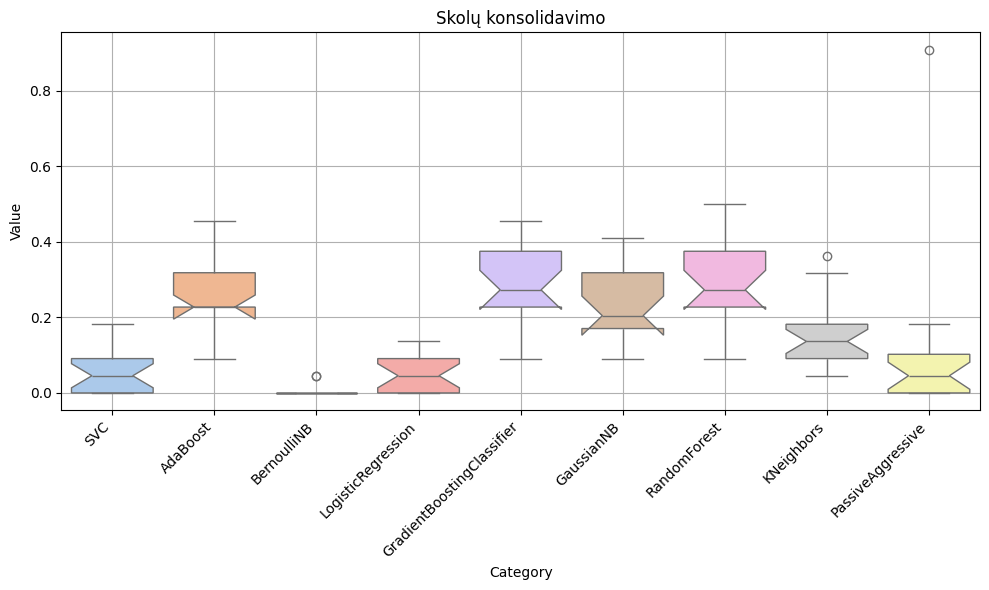

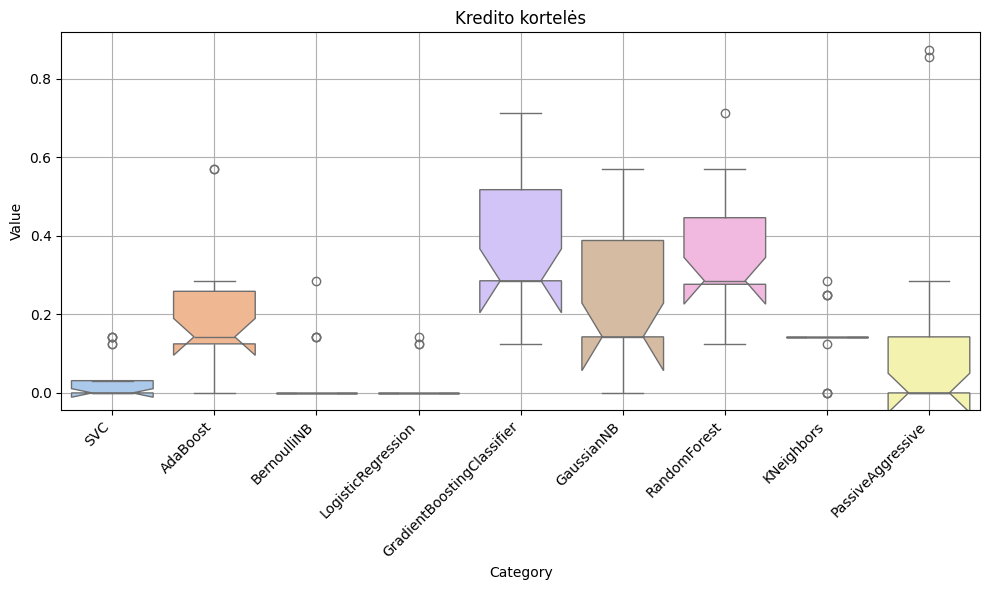

In [82]:
scores_svc_debt_subset = cross_val_score(svc_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_svc_debt_subset.mean():.4f}")

scores_svc_credit_subset = cross_val_score(svc_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_svc_credit_subset.mean():.4f}")

scores_AdaBoost_debt_subset = cross_val_score(AdaBoost_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_AdaBoost_debt_subset.mean():.4f}")

scores_AdaBoost_credit_subset = cross_val_score(AdaBoost_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_AdaBoost_credit_subset.mean():.4f}")

scores_BernoulliNB_debt_subset = cross_val_score(BernoulliNB_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_BernoulliNB_debt_subset.mean():.4f}")

scores_BernoulliNB_credit_subset = cross_val_score(BernoulliNB_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_BernoulliNB_credit_subset.mean():.4f}")

scores_lr_debt_subset = cross_val_score(lr_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_lr_debt_subset.mean():.4f}")

scores_lr_credit_subset = cross_val_score(lr_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_lr_credit_subset.mean():.4f}")

scores_gb_debt_subset = cross_val_score(gb_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gb_debt_subset.mean():.4f}")

scores_gb_credit_subset = cross_val_score(gb_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gb_credit_subset.mean():.4f}")

scores_gnb_debt_subset = cross_val_score(gnb_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gnb_debt_subset.mean():.4f}")

scores_gnb_credit_subset = cross_val_score(gnb_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gnb_credit_subset.mean():.4f}")

scores_rf_debt_subset = cross_val_score(rf_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_rf_debt_subset.mean():.4f}")

scores_rf_credit_subset = cross_val_score(rf_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_rf_credit_subset.mean():.4f}")

scores_knn_debt_subset = cross_val_score(knn_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_knn_debt_subset.mean():.4f}")

scores_knn_credit_subset = cross_val_score(knn_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_knn_credit_subset.mean():.4f}")

scores_pa_debt_subset = cross_val_score(pa_pipeline, X_debt_subset, y_debt_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_pa_debt_subset.mean():.4f}")

scores_pa_credit_subset = cross_val_score(pa_pipeline, X_credit_subset, y_credit_subset, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_pa_credit_subset.mean():.4f}")

df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20 + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_debt_subset, scores_AdaBoost_debt_subset, scores_BernoulliNB_debt_subset, scores_lr_debt_subset, scores_gb_debt_subset, scores_gnb_debt_subset, scores_rf_debt_subset, scores_knn_debt_subset, scores_pa_debt_subset])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Skolų konsolidavimo")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20  + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_credit_subset, scores_AdaBoost_credit_subset, scores_BernoulliNB_credit_subset, scores_lr_credit_subset, scores_gb_credit_subset, scores_gnb_credit_subset, scores_rf_credit_subset, scores_knn_credit_subset, scores_pa_credit_subset])
})


plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Kredito kortelės")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

## Ismoketa, visi pozymiai, specifiskumas

In [83]:
debt_data_paid = sampled_data[sampled_data['purpose'] == 'debt_consolidation']
debt_data_paid = debt_data_paid.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'credit.policy'])
debt_data_paid.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
2156,26.40,697,3840.000000,5132,41.4,2,0,0,0,45000.000056
2157,13.02,687,2130.000000,9451,33.3,4,0,0,1,37499.999927
2158,19.52,672,4529.958333,8443,33.2,4,1,0,0,38000.000049
2159,16.19,672,6360.000000,5494,83.2,4,0,0,0,60999.999808
2160,26.52,667,2672.958333,21300,65.5,4,0,0,0,55199.999875


In [84]:
credit_data_paid = sampled_data[sampled_data['purpose'] == 'credit_card']
credit_data_paid = credit_data_paid.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc', 'credit.policy'])
credit_data_paid.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
1399,16.87,677,3779.958333,2488,62.2,5,0,0,0,34999.999983
1400,15.14,647,3299.000000,36662,82.9,0,0,0,0,49999.999779
1401,4.51,727,600.000000,669,7.0,0,0,0,0,49999.999779
1402,6.24,657,2490.000000,8558,80.7,3,0,0,0,71000.000282
1403,12.26,702,6960.000000,56200,57.4,4,0,0,0,159999.999325


In [86]:
X_debt_paid = debt_data_paid.drop(['not.fully.paid'], axis=1)
y_debt_paid = debt_data_paid['not.fully.paid']

X_credit_paid = credit_data_paid.drop(['not.fully.paid'], axis=1)
y_credit_paid= credit_data_paid['not.fully.paid']

c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Konsolidavimo (Specifiškumas): 1.0000
Kredito kortelės (Specifiškumas): 1.0000
Konsolidavimo (Specifiškumas): 0.9990
Kredito kortelės (Specifiškumas): 0.9939
Konsolidavimo (Specifiškumas): 1.0000
Kredito kortelės (Specifiškumas): 0.9955
Konsolidavimo (Specifiškumas): 0.9995
Kredito kortelės (Specifiškumas): 0.9970
Konsolidavimo (Specifiškumas): 0.9911
Kredito kortelės (Specifiškumas): 0.9758
Konsolidavimo (Specifiškumas): 0.9062
Kredito kortelės (Specifiškumas): 0.9470
Konsolidavimo (Specifiškumas): 0.9966
Kredito kortelės (Specifiškumas): 0.9879
Konsolidavimo (Specifiškumas): 0.9704
Kredito kortelės (Specifiškumas): 0.9909


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', pe

Konsolidavimo (Specifiškumas): 0.9328
Kredito kortelės (Specifiškumas): 0.9530


c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', pe

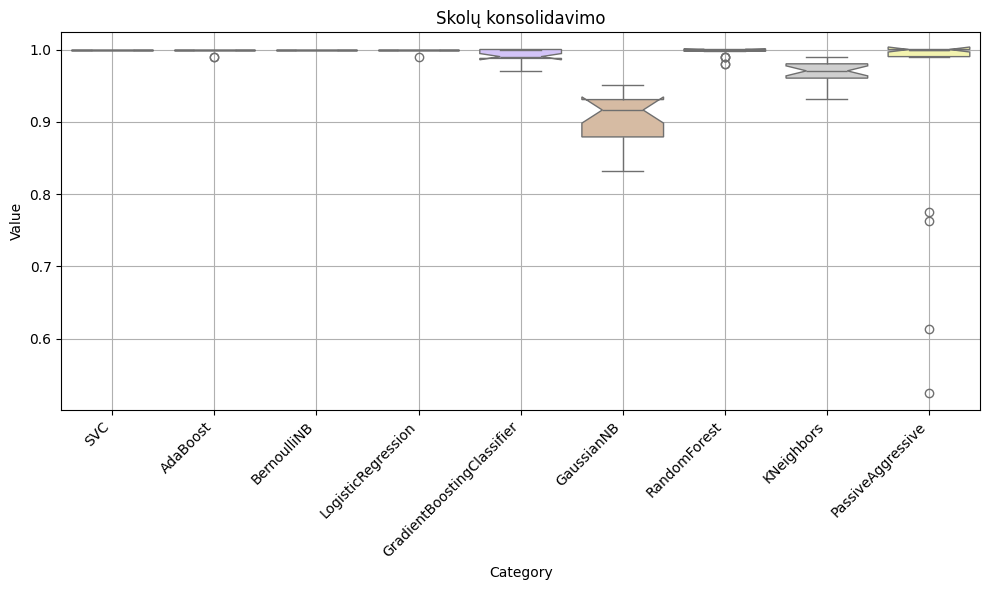

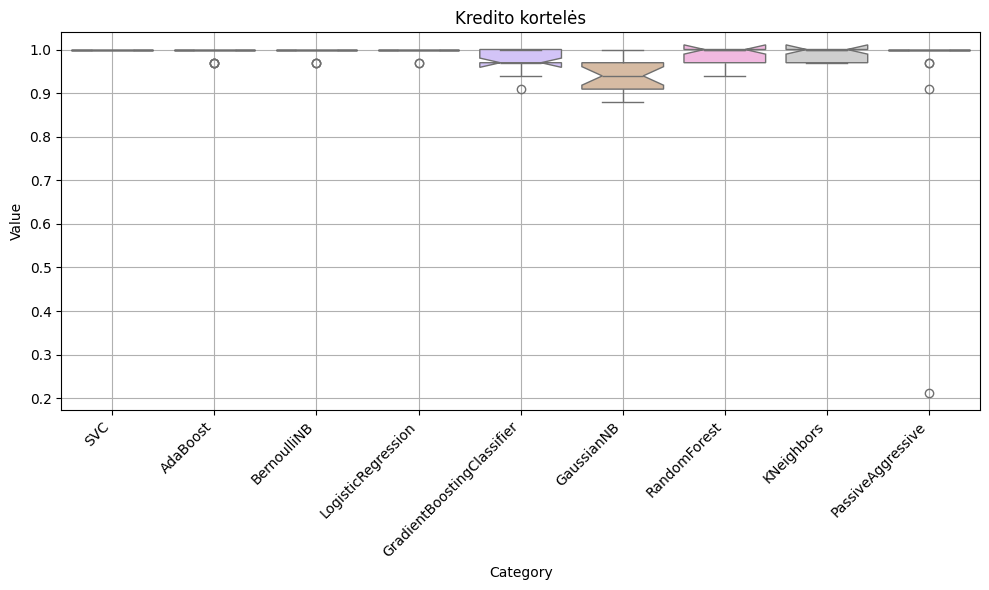

In [93]:
svc_pipeline = make_pipeline(MinMaxScaler(), svm.SVC())
AdaBoost_pipeline = make_pipeline(MinMaxScaler(), AdaBoost())
BernoulliNB_pipeline = make_pipeline(MinMaxScaler(), BernoulliNB())
lr_pipeline = make_pipeline(MinMaxScaler(), LogisticRegression())
gb_pipeline = make_pipeline(MinMaxScaler(), GradientBoostingClassifier())
gnb_pipeline = make_pipeline(MinMaxScaler(), GaussianNB())
rf_pipeline = make_pipeline(MinMaxScaler(), RandomForestClassifier())
knn_pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier())
pa_pipeline = make_pipeline(MinMaxScaler(), PassiveAggressiveClassifier())

scores_svc_debt_paid = cross_val_score(svc_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_svc_debt_paid.mean():.4f}")

scores_svc_credit_paid = cross_val_score(svc_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_svc_credit_paid.mean():.4f}")

scores_AdaBoost_debt_paid = cross_val_score(AdaBoost_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_AdaBoost_debt_paid.mean():.4f}")

scores_AdaBoost_credit_paid = cross_val_score(AdaBoost_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_AdaBoost_credit_paid.mean():.4f}")

scores_BernoulliNB_debt_paid = cross_val_score(BernoulliNB_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_BernoulliNB_debt_paid.mean():.4f}")

scores_BernoulliNB_credit_paid = cross_val_score(BernoulliNB_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_BernoulliNB_credit_paid.mean():.4f}")

scores_lr_debt_paid = cross_val_score(lr_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_lr_debt_paid.mean():.4f}")

scores_lr_credit_paid = cross_val_score(lr_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_lr_credit_paid.mean():.4f}")

scores_gb_debt_paid = cross_val_score(gb_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gb_debt_paid.mean():.4f}")

scores_gb_credit_paid = cross_val_score(gb_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gb_credit_paid.mean():.4f}")

scores_gnb_debt_paid = cross_val_score(gnb_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_gnb_debt_paid.mean():.4f}")

scores_gnb_credit_paid = cross_val_score(gnb_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_gnb_credit_paid.mean():.4f}")

scores_rf_debt_paid = cross_val_score(rf_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_rf_debt_paid.mean():.4f}")

scores_rf_credit_paid = cross_val_score(rf_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_rf_credit_paid.mean():.4f}")

scores_knn_debt_paid = cross_val_score(knn_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_knn_debt_paid.mean():.4f}")

scores_knn_credit_paid = cross_val_score(knn_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_knn_credit_paid.mean():.4f}")

scores_pa_debt_paid = cross_val_score(pa_pipeline, X_debt_paid, y_debt_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Konsolidavimo (Specifiškumas): {scores_pa_debt_paid.mean():.4f}")

scores_pa_credit_paid = cross_val_score(pa_pipeline, X_credit_paid, y_credit_paid, cv=cv_strategy, scoring=specificity_scorer)
print(f"Kredito kortelės (Specifiškumas): {scores_pa_credit_paid.mean():.4f}")

df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20 + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_debt_paid, scores_AdaBoost_debt_paid, scores_BernoulliNB_debt_paid, scores_lr_debt_paid, scores_gb_debt_paid, scores_gnb_debt_paid, scores_rf_debt_paid, scores_knn_debt_paid, scores_pa_debt_paid])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Skolų konsolidavimo")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20  + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_credit_paid, scores_AdaBoost_credit_paid, scores_BernoulliNB_credit_paid, scores_lr_credit_paid, scores_gb_credit_paid, scores_gnb_credit_paid, scores_rf_credit_paid, scores_knn_credit_paid, scores_pa_credit_paid])
})


plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Kredito kortelės")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

-----

# Mokymo ir testavimo aibė

In [ ]:
X_train_debt, X_test_debt, y_train_debt, y_test_debt = train_test_split(debt_data.drop(columns=['not.fully.paid', 'credit.policy']), debt_data['credit.policy'], test_size=0.2, random_state=123, stratify=debt_data['credit.policy'])

X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(credit_data.drop(columns=['not.fully.paid', 'credit.policy']), credit_data['credit.policy'], test_size=0.2, random_state=123, stratify=credit_data['credit.policy'])

In [ ]:
X_train_debt.head()

# Min-Max normalizavimas

In [ ]:
min_max_scaler = MinMaxScaler()

X_debt_norm = min_max_scaler.fit_transform(debt_data.drop(columns=['not.fully.paid', 'credit.policy']))
X_train_debt_norm = min_max_scaler.fit_transform(X_train_debt)
X_test_debt_norm = min_max_scaler.transform(X_test_debt)

X_credit_norm = min_max_scaler.fit_transform(credit_data.drop(columns=['not.fully.paid', 'credit.policy']))
X_train_credit_norm = min_max_scaler.fit_transform(X_train_credit)
X_test_credit_norm = min_max_scaler.transform(X_test_credit)

# Dimensijos mažinimas

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)

X_debt_tsne = tsne.fit_transform(X_debt_norm)
X_credit_tsne = tsne.fit_transform(X_credit_norm)

In [ ]:
X_train_debt_tsne, X_test_debt_tsne, y_train_debt_tsne, y_test_debt_tsne = train_test_split(X_debt_tsne, debt_data['credit.policy'], test_size=0.2, random_state=123, stratify=debt_data['credit.policy'])
X_train_credit_tsne, X_test_credit_tsne, y_train_credit_tsne, y_test_credit_tsne = train_test_split(X_credit_tsne, credit_data['credit.policy'], test_size=0.2, random_state=123, stratify=credit_data['credit.policy'])

# Parametrų atrinkimas
## AdaBoost
### Origiinali dimensija

In [ ]:
AdaModel = AdaBoost(random_state = 42)

param_grid = {
    'n_estimators': [146, 149, 150, 151, 400, 450],
    'learning_rate': [1.15, 1.2, 1.25, 1.4, 1.45, 1.5, 1.6]
}

grid_search_debt = GridSearchCV(
    estimator=AdaModel,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_debt.fit(X_train_debt_norm, y_train_debt)

# X_test_debt_norm

print(grid_search_debt.best_params_)
print(grid_search_debt.best_score_)
best_adaBoost_debt = grid_search_debt.best_estimator_
print(best_adaBoost_debt.score(X_test_debt_norm, y_test_debt))

AdaModel = AdaBoost(random_state = 42)

grid_search_credit = GridSearchCV(
    estimator=AdaModel,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_credit.fit(X_train_credit_norm, y_train_credit)

print(grid_search_credit.best_params_)
print(grid_search_credit.best_score_)
best_adaBoost_debt = grid_search_credit.best_estimator_
print(best_adaBoost_debt.score(X_test_credit_norm, y_test_credit))